<center>

## **Voice Gender Detection**

</center>

---

### **Step 1: Load Dataset and Labels <span style="color: yellow;">&</span> Extract MFCC Features**

In [ ]:
import librosa
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split


def extract_mfcc(audio_file, num_mfcc=13):
    """Extract MFCC features from an audio file."""
    y, sr = librosa.load(audio_file, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=num_mfcc)
    return np.mean(mfccs, axis=1)  # Taking mean to reduce dimensionality

def load_dataset(dataset_path):
    X, y = [], []
    
    for label, gender in enumerate(["male", "female"]):  # Male = 0, Female = 1
        folder_path = os.path.join(dataset_path, gender)
        for file in glob.glob(os.path.join(folder_path, "*.wav")):
            mfcc_features = extract_mfcc(file)
            X.append(mfcc_features)
            y.append(label)

    return np.array(X), np.array(y)

# Load dataset
dataset_path = "audio_files"  # dataset folder path
X, y = load_dataset(dataset_path)


**Extract MFCC Function**
- Loading with `librosa.load`: This function reads the audio file and returns the audio signal and sampling rate.

**MFCC (Mel Frequency Cepstral Coefficients)** - are features that represent the short-term power spectrum of sound.

**Why MFCC ? `librosa.feature.mfcc`**
- They approximate the human auditory system’s response, focusing on perceptually meaningful frequency bands.
- They provide a compact representation of the spectral properties of audio.
- This makes them very effective in tasks such as speech and music recognition.

**Averaging the MFCCs:**
- Since each audio file produce a variable number of frames (time steps), taking the **mean** across time yields a fixed-length vector which is easier for classifiers to work with.

#### **MFCC Visualization of <span style="color:rgb(81, 133, 229);">Male</span> & <span style="color:rgb(213, 88, 203);">Female</span> Audio**

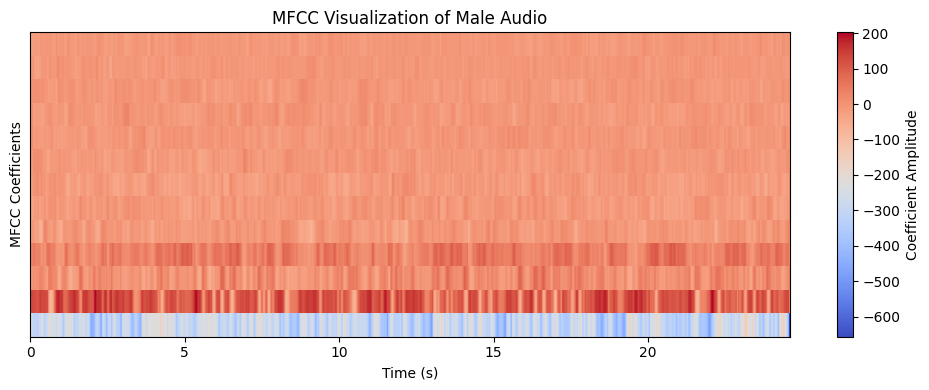

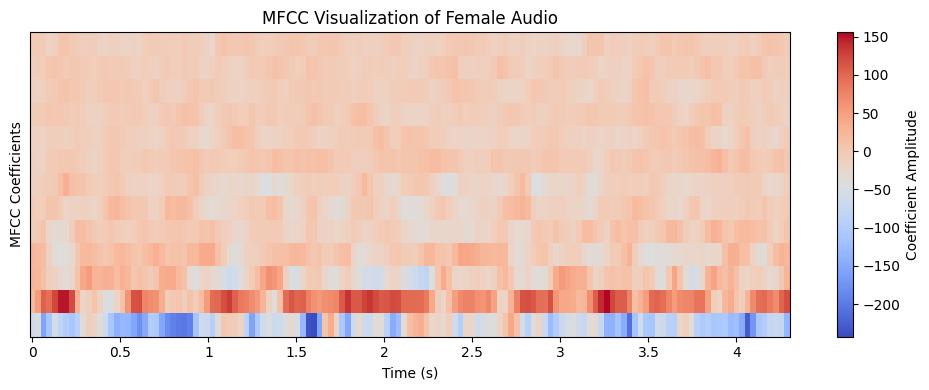

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Audio path
audio_path = r"audio_files\male\10.wav"
signal, sr = librosa.load(audio_path, sr=None)  # 'sr=None' preserves the original sampling rate

# Compute MFCC features
# Here, we extract 13 MFCC coefficients which is common practice.
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

# Visualize the MFCCs
plt.figure(figsize=(10, 4))  # Set the figure size for better readability

# Use librosa's specshow to display the MFCCs as a spectrogram-like image
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(label='Coefficient Amplitude')  # Add a colorbar to interpret the amplitude values
plt.title('MFCC Visualization of Male Audio')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Coefficients')
plt.tight_layout()  # Adjust the layout to prevent clipping of labels
plt.show()  # Display the plot

# ------------------------------------------------------------------------------------------------------------------------

# Audio path
audio_path = r"audio_files\female\612.wav"
signal, sr = librosa.load(audio_path, sr=None)  # 'sr=None' preserves the original sampling rate

# Compute MFCC features
# Here, we extract 13 MFCC coefficients which is common practice.
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

# Visualize the MFCCs
plt.figure(figsize=(10, 4))  # Set the figure size for better readability

# Use librosa's specshow to display the MFCCs as a spectrogram-like image
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar(label='Coefficient Amplitude')  # Add a colorbar to interpret the amplitude values
plt.title('MFCC Visualization of Female Audio')
plt.xlabel('Time (s)')
plt.ylabel('MFCC Coefficients')
plt.tight_layout()  # Adjust the layout to prevent clipping of labels
plt.show()  # Display the plot


**Amplitude Range (Color Intensity):**
- The male audio has a wider amplitude range (from around -600 to 200).
- The female audio has a narrower amplitude range (from around -200 to 150).
- This indicates that <span style="color:rgb(81, 133, 229);">Male Speech</span> has **greater energy variations** in MFCC coefficients.

**Color Variation (Harmonics and Pitch Differences):**
- The male MFCC spectrogram has dense red bands, especially in the lower coefficient range, suggesting **strong low-frequency components.**
- The female MFCC spectrogram appears more spread out with less intensity in lower frequencies, implying **higher fundamental frequency (pitch).**
- This aligns with the fact that <span style="color:rgb(81, 133, 229);">Male</span> voices generally have <span style="color: yellow;">lower pitch</span>, while <span style="color:rgb(213, 88, 203);">Female</span> voices have <span style="color: yellow;">higher pitch</span>.

### **Step 2: Train an SVM Classifier**

In [33]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train SVM classifier
clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
clf.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear'))])

**What is SVM (Support Vector Machine)?**
- Support Vector Machine (SVM) is a supervised learning algorithm mainly used for classification and regression tasks.
- It is particularly effective for high-dimensional datasets and works by finding the <span style="color: yellow;">optimal decision boundary (hyperplane)</span>  that best separates different classes.

SVM is based on the concept of maximizing the margin between data points of different classes.\
It identifies the support vectors, which are the most important data points that define the hyperplane.

---
**SVM is used here because:**
- It works well with high-dimensional data (e.g., extracted audio features).
- It is robust to noise and effective even with small datasets.
- It provides a clear decision boundary for classification.
- The `kernel="linear"` is computationally efficient and works well for many voice-related problems.

**Why a Linear Kernel?**
- In many voice classification problems, the data is <span style="color: yellow;">linearly separable</span>, meaning a straight line (or hyperplane) can effectively classify genders.
- A linear kernel is **faster and requires less computation** compared to non-linear kernels.
- It helps in better interpretability compared to complex non-linear decision boundaries.

**Simplifies** A linear kernel is used here because it is simple, efficient, and works well for this problem.

---

**Why Use `StandardScaler()`?**
- `StandardScaler()` from `sklearn.preprocessing` is used for feature scaling, meaning it <span style="color: yellow;">normalizes</span> the dataset so that all features have a **Mean of 0 & SD of 1.**

**Why is this important for SVM?**
- SVM is sensitive to feature scales – If one feature has a much larger scale than another, it can dominate the model, leading to poor performance.
- Improves convergence speed – Scaling helps in faster training of the SVM model.
- Avoids biased hyperplane placement – Without scaling, features with larger values might skew the decision boundary.

### **Step 3: Generate Confusion Matrix**

<Figure size 600x500 with 0 Axes>

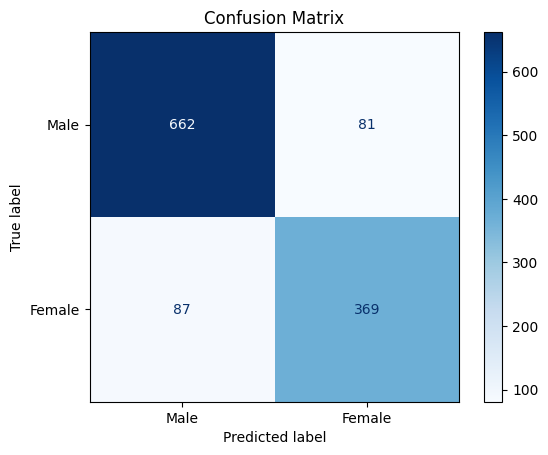

In [34]:
# Generate confusion matrix
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Male", "Female"])

# Plot confusion matrix
plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix")

plt.show()

### **Step 4: Model Evaluation**

In [39]:
#  Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 85.99%


**Accuracy Score:**
- This metric measures the ratio of correct predictions to the total number of predictions.
- It is a common and straightforward metric when classes are balanced.

**Why accuracy instead of precision, recall, or F1 score?**
- In many projects, if the dataset is relatively balanced (i.e., each class has roughly the same number of samples), accuracy provides a clear overall performance metric.
- **Precision, recall, and F1** are particularly useful in **imbalanced datasets or when the costs of false positives and false negatives** are very different.

Accuracy is easier to interpret for a quick performance check.

### **Step 5: Predict Gender for a New Audio File**

In [46]:
def predict_gender(audio_file, model):
    mfcc_test = extract_mfcc(audio_file)
    print(mfcc_test)
    gender = model.predict([mfcc_test])[0]
    return "Female" if gender == 1 else "Male"

# Test with a new audio file
test_file = r"audio_files\female\2310.wav"
prediction = predict_gender(test_file, clf)
print(f"Predicted Gender: {prediction}")


# Average = -14.2052513738

[-126.03511      73.84524     -25.103226     -8.667207    -41.849415
  -18.651878    -27.710094    -15.334021     -6.8893566     0.27560684
    4.707259      1.1973909     5.799543  ]
Predicted Gender: Female
